## 1. Load the dataset and examine its structure.
- Load the CSV file into pandas.
- Display the first 5 rows.
- Report the number of rows and columns.
- Print the column names.
- Use info() to inspect the dataset.
Answer:
- Which variable will be the target?
- Which columns appear to be numerical?
- Which columns appear to be categorical?

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Assgmt2/SLCM_rent_arrears_student_clean.csv")
display(df.head())
print("Rows and columns:", df.shape)
print("Column names:", df.columns.tolist())
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,record_id,adults_in_household,children_in_household,household_has_65plus,monthly_household_income,income_sources,employment_status,has_housing_voucher,eviction_in_progress,behind_on_utilities,main_reason_behind_on_rent,intake_quarter,monthly_rent,past_due_rent
0,SLCM_0001,1,1,No,293.0,"Food benefits - TANF/SNAP, No income, Other",Unemployed but want to find work,No,I don't know,Yes,Other,2026-Q1,1560.0,3100.0
1,SLCM_0002,0,3,No,2000.0,Child support,Employed,No,I don't know,Yes,Unexpected expense,2026-Q3,1550.0,7300.0
2,SLCM_0003,1,0,No,400.0,Food benefits - TANF/SNAP,Unemployed but want to find work,I don't know,Yes,Yes,Lost a job/had hours cut,2025-Q4,0.0,6000.0
3,SLCM_0004,2,0,No,2500.0,Full-time employment,Unemployed and not looking for work,No,Yes,Yes,Lost a job/had hours cut,2026-Q2,1299.0,2500.0
4,SLCM_0005,1,2,No,14.0,Part-time employment,Employed,No,Yes,No,Unexpected expense,2025-Q4,1105.5,1205.5


Rows and columns: (1754, 14)
Column names: ['record_id', 'adults_in_household', 'children_in_household', 'household_has_65plus', 'monthly_household_income', 'income_sources', 'employment_status', 'has_housing_voucher', 'eviction_in_progress', 'behind_on_utilities', 'main_reason_behind_on_rent', 'intake_quarter', 'monthly_rent', 'past_due_rent']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754 entries, 0 to 1753
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   1754 non-null   object 
 1   adults_in_household         1754 non-null   int64  
 2   children_in_household       1754 non-null   int64  
 3   household_has_65plus        1754 non-null   object 
 4   monthly_household_income    1646 non-null   float64
 5   income_sources              1754 non-null   object 
 6   employment_status           1754 non-null   object 
 7   has_housing_voucher         

The target is past_due_rent, the amount of rent owed. There are 1,754 rows and 14 columns. The numerical columns are adults_in_household, children_in_household, monthly_household_income, monthly_rent, and the target past_due_rent. The categorical are household_has_65plus, income_sources, employment_status, has_housing_voucher, eviction_in_progress, behind_on_utilities, main_reason_behind_on_rent, and intake_quarter. Record_id is stored as text but is an identifier, so it will be excluded.




## 2. Investigate missing values.
- Calculate the number of missing values in every column.
- Identify which variables contain missing data.
- Briefly describe how you plan to handle those missing values before modeling.
Do not simply remove all rows with missing data unless you can justify that decision.

In [18]:
missing = df.isna().sum()
display(missing.rename("Missing values").to_frame())
print("Columns with missing values:")
display(missing[missing > 0].rename("Missing values").to_frame())

,Missing values
record_id,0
adults_in_household,0
children_in_household,0
household_has_65plus,0
monthly_household_income,108
income_sources,0
employment_status,0
has_housing_voucher,0
eviction_in_progress,1
behind_on_utilities,7


Columns with missing values:


,Missing values
monthly_household_income,108
eviction_in_progress,1
behind_on_utilities,7
main_reason_behind_on_rent,16
monthly_rent,8


Missing values occur in monthly household income (108), monthly rent (8), eviction status (1), utility status (7), and the reason for falling behind (16). I will replace missing numerical values with the training-set median and missing categories with the label Missing. This keeps households in the analysis and does not guess their categorical responses. The target has no missing values. Responses such as "I don't know" and "Prefer not to answer" are recorded categories, so I will preserve them. Imputation will be performed only on training data.

## 3. Explore the target variable: past_due_rent.
Calculate:
- count
- mean
- median
- standard deviation
- minimum
- maximum
Create:
- a histogram
- a boxplot
Answer:
- What does the distribution look like?
- Is the distribution symmetric or skewed?
- Are the mean and median similar?
- Do you notice any unusually high values?
- Why might rent-arrears data naturally contain a wide range of values?
Do not automatically remove an observation simply because it is high.

,past_due_rent
count,1754.000000
mean,2408.006933
median,2000.000000
std,2089.515372
min,0.000000
max,20000.000000


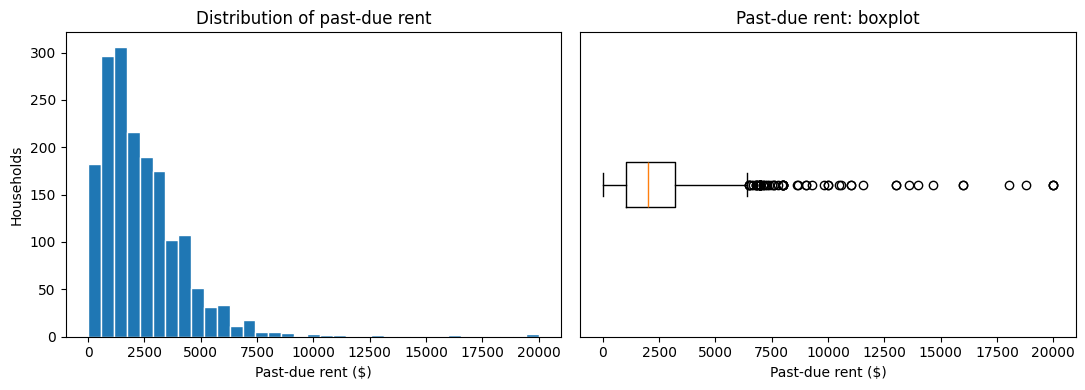

In [19]:
target_summary = df["past_due_rent"].agg(["count", "mean", "median", "std", "min", "max"])
display(target_summary.rename("past_due_rent").to_frame())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["past_due_rent"], bins=35, edgecolor="white")
axes[0].set(title="Distribution of past-due rent", xlabel="Past-due rent ($)", ylabel="Households")
axes[1].boxplot(df["past_due_rent"], vert=False)
axes[1].set(title="Past-due rent: boxplot", xlabel="Past-due rent ($)", yticks=[])
plt.tight_layout()
plt.show()

The distribution is strongly right-skewed. Most households owe much less than the largest amounts, but a long right tail extends to 20,000. The mean is 2,408.01 and the median is 2,000.00, so the mean is higher because large amounts pull it upward. The sample standard deviation is 2,089.52, and the minimum is $0. The boxplot marks many high values as unusual, but that does not prove they are errors. Differences in monthly rent and the number of missed payments could naturally produce a wide range of amounts. Thus, because these values are plausible, I will retain the high values.

## 4. Create your input features and target.
Create X and y using past_due_rent as the target. Do not use record_id as an input feature.
Answer:
- Why should record_id not be used to predict past-due rent?

In [20]:
X = df.drop(columns=["record_id", "past_due_rent"])
y = df["past_due_rent"]
print("X:", X.shape)
print("y:", y.shape)

X: (1754, 12)
y: (1754,)


record_id identifies a row and does not describe a household's financial situation. Including it could make the model learn arbitrary record-specific patterns that do not generalize to new households. The target is also excluded from X so the model cannot use the answer as an input.

## 5. Separate the numerical and categorical features.
- Create lists containing numerical features and categorical features.
- Display both lists.
- Briefly explain why machine-learning models require different preparation steps for numerical and ategorical variables.

In [21]:
numerical_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['adults_in_household', 'children_in_household', 'monthly_household_income', 'monthly_rent']
Categorical features: ['household_has_65plus', 'income_sources', 'employment_status', 'has_housing_voucher', 'eviction_in_progress', 'behind_on_utilities', 'main_reason_behind_on_rent', 'intake_quarter']


There are four numerical predictors and eight categorical predictors. Numerical variables need missing-value handling and scaling. Categorical variables need missing-value handling and encoding because text categories cannot directly enter these regression calculations. I treat each recorded income_sources combination as a category for this model. This creates many categories, some rare; separately encoding each income source is a possible future improvement. Quarter is also treated as a category, not as an arbitrary integer.

## 6. Split the data into training and testing sets.
Use test_size=0.20 and random_state=42.
- Report the dimensions of X_train, X_test, y_train, and y_test.
- Why should the model be evaluated using data that was not used during training?

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
for name, data in [("X_train", X_train), ("X_test", X_test),
                   ("y_train", y_train), ("y_test", y_test)]:
    print(name, data.shape)

X_train (1403, 12)
X_test (351, 12)
y_train (1403,)
y_test (351,)


## 7. Prepare the numerical variables.
Create an appropriate numerical preprocessing pipeline. Your pipeline should consider missing values and
feature scaling. Use appropriate tools such as SimpleImputer and StandardScaler.
Explain:
- How did you handle missing numerical values?
- Why might feature scaling matter when comparing Linear, Ridge, and Lasso models?

In [23]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
print(numerical_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


I use the training median for missing numerical values because it is less affected by unusually large values than the mean. StandardScaler centers each numerical predictor and scales it using the training standard deviation. Scaling is especially important for Ridge and Lasso because their penalties depend on coefficient size, and dollars and household counts start on very different scales. Ordinary unpenalized linear regression generally gives equivalent predictions after this scaling, but scaling can improve numerical conditioning. The target stays in dollars.

## 8. Prepare the categorical variables.
Create an appropriate categorical preprocessing pipeline. Your pipeline should consider missing values and
converting text categories into numerical values. Use appropriate tools such as SimpleImputer and
OneHotEncoder.
Answer:
- Why can the regression models not directly use values such as employment categories?
- Why is one-hot encoding appropriate for these variables?
- Why would assigning arbitrary numbers such as 1, 2, 3, and 4 to unordered categories potentially be misleading?

In [24]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore", drop="first", sparse_output=False
    ))
])
print(categorical_pipeline)

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='Missing', strategy='constant')),
                ('encoder',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False))])


One-hot encoding represents the categories using binary indicator columns. These regression models need numbers for their calculations, and one-hot encoding avoids inventing an order among categories such as employment statuses. Assigning them 1, 2, 3, and 4 would imply an order and equal spacing that may not exist. I drop one reference level per variable to avoid redundant indicator columns alongside the intercept. handle_unknown ignore lets the pipeline process a category absent from training; it receives zeros in that variable's indicator columns. With this reference coding, an unseen category is therefore indistinguishable from the reference category, which is a limitation. A warning about unseen income-source combinations during prediction is expected, not a failed fit.

## 9. Combine your preprocessing steps.
Use a ColumnTransformer to combine the numerical and categorical preprocessing. Your preprocessing should
be reusable inside the regression pipelines you create in the next part.
Explain briefly why using a preprocessing pipeline is useful.

In [25]:
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['adults_in_household',
                                  'children_in_household',
                                  'monthly_household_income', 'monthly_rent']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Missing',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                   

The ColumnTransformer applies the appropriate preparation to each type of column and combines the results. Putting it inside each model pipeline ensures that medians, scaling values, and categories are learned from training data only. The same fitted transformations are then applied to testing data and hypothetical households. This prevents preprocessing leakage and makes the steps reusable.

## 10. Build a Multiple Linear Regression model.
Create a pipeline containing your preprocessing and a Linear Regression model. Train the model using the
training data and make predictions for the testing data.
Calculate:
- RMSE
- R2
Create an Actual vs. Predicted scatterplot with actual values on the x-axis, predicted values on the y-axis, and a
diagonal reference line showing where perfect predictions would fall.
Answer:
- What does RMSE represent in this problem?
- What does the R2 score tell you?
- Based on the graph, how closely do the predictions match the actual values?
- Do you notice cases where the model makes large prediction errors?

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,RMSE,R2
0,Linear Regression,1850.787,0.164


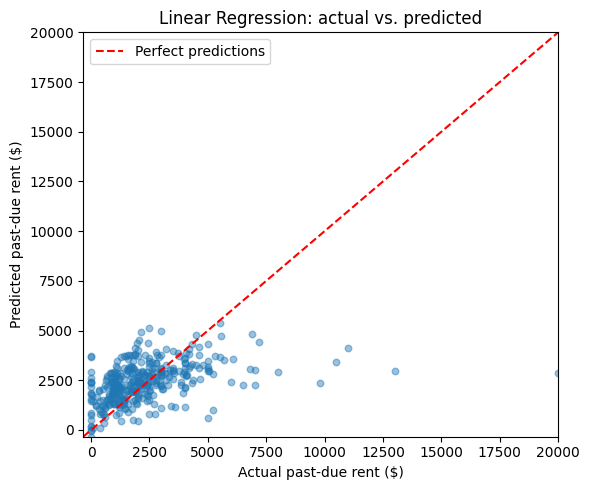

In [26]:
from sklearn.base import clone

def evaluate_model(name, pipeline):
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    result = {
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R2": r2_score(y_test, predictions)
    }
    display(pd.DataFrame([result]).round(3))
    return result, predictions

linear_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LinearRegression())
])
linear_result, linear_predictions = evaluate_model("Linear Regression", linear_model)

def actual_vs_predicted(actual, predicted, title):
    lower = min(0, np.min(predicted), np.min(actual))
    upper = max(np.max(actual), np.max(predicted))
    plt.figure(figsize=(6, 5))
    plt.scatter(actual, predicted, alpha=0.45, s=22)
    plt.plot([lower, upper], [lower, upper], "r--", label="Perfect predictions")
    plt.xlim(lower, upper)
    plt.ylim(lower, upper)
    plt.xlabel("Actual past-due rent ($)")
    plt.ylabel("Predicted past-due rent ($)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

actual_vs_predicted(y_test, linear_predictions, "Linear Regression: actual vs. predicted")

Linear Regression has a test RMSE of 1,850.79 and R2 of 0.164. RMSE measures prediction error in dollars, with large errors receiving extra weight; it is not the mean absolute error or a guaranteed error range. R2 indicates that the model accounts for about 16.4% of test-set variation relative to predicting the test-set mean. This is limited predictive power. In the scatterplot, predictions are concentrated in the lower range and often fall far below the diagonal for large actual amounts. One household owing $20,000 receives a prediction of about $2,861. Some predictions are negative, which is not realistic for arrears; I retain the raw predictions in the comparison rather than silently changing them.

## 11. Build a Polynomial Regression model.
Real-world relationships are not always perfectly linear. For this model, use PolynomialFeatures(degree=2,
include_bias=False). Apply polynomial transformation to the appropriate numerical variables. Do not
automatically apply polynomial expansion to all one-hot encoded categorical variables.
Train the model and calculate RMSE and R2.
Answer:
- Did Polynomial Regression perform better or worse than Linear Regression?
- What does a degree-2 polynomial allow the model to represent that Linear Regression cannot?
- Why could using a very high polynomial degree lead to overfitting?
- Did making the model more complicated automatically make it better?

In [27]:
polynomial_numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
    ("polynomial_scaler", StandardScaler())
])
polynomial_preprocessor = ColumnTransformer([
    ("num", polynomial_numerical_pipeline, numerical_features),
    ("cat", clone(categorical_pipeline), categorical_features)
])
polynomial_model = Pipeline([
    ("preprocessor", polynomial_preprocessor),
    ("model", LinearRegression())
])
polynomial_result, polynomial_predictions = evaluate_model(
    "Polynomial Regression", polynomial_model
)
print("Numerical terms after expansion:",
      polynomial_model.named_steps["preprocessor"].named_transformers_["num"]
      .named_steps["polynomial"].n_output_features_)

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,RMSE,R2
0,Polynomial Regression,1863.608,0.153


Numerical terms after expansion: 14


Polynomial Regression has RMSE $1,863.61 and R2 0.153, so it performs slightly worse than Linear Regression. Degree 2 adds squared numerical terms and pairwise numerical interactions, allowing curved relationships and relationships that depend on combinations of predictors. The four numerical inputs become 14 terms; the categorical indicators are not expanded. A higher degree would add more terms and could fit noise instead of useful patterns. Here, more complexity did not improve held-out prediction.

## 12. Build a Ridge Regression model.
Create a Ridge Regression pipeline using the same training and testing data. Choose a reasonable value for
alpha. You may experiment with more than one value.
Calculate RMSE and R2.
Answer:
- How does Ridge Regression compare with Linear Regression?
- What does regularization do?
- Why can regularization be useful when a model contains many features?

In [28]:
ridge_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", Ridge(alpha=10.0))
])
ridge_result, ridge_predictions = evaluate_model("Ridge Regression", ridge_model)

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,RMSE,R2
0,Ridge Regression,1829.273,0.184


Ridge has RMSE 1,829.27 and R2 0.184, a small improvement over Linear Regression. I chose alpha 10 as fixed starting value rather than selecting it from test-set performance. Ridge adds a penalty on squared coefficient sizes, shrinking coefficients to reduce sensitivity to noise and correlated predictors. This can help with the many indicators created by income-source categories. Regularization trades some training fit for potentially better generalization. Alpha is not claimed to be optimal; further tuning should use cross-validation within the training set.

## 13. Build a Lasso Regression model.
Create a Lasso Regression pipeline using the same training and testing data. Choose a reasonable value for
alpha.
Calculate RMSE and R2.
Answer:
- How does Lasso compare with Linear and Ridge Regression?
- What is an important difference between Ridge and Lasso?
- What can happen to some coefficients when Lasso is used?

In [29]:
lasso_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", Lasso(alpha=10.0, max_iter=100000))
])
lasso_result, lasso_predictions = evaluate_model("Lasso Regression", lasso_model)
lasso_coefficients = lasso_model.named_steps["model"].coef_
print("Total coefficients:", len(lasso_coefficients))
print("Coefficients set to zero:", np.sum(lasso_coefficients == 0))
print("Solver iterations:", lasso_model.named_steps["model"].n_iter_)

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,RMSE,R2
0,Lasso Regression,1827.703,0.185


Total coefficients: 111
Coefficients set to zero: 85
Solver iterations: 15


Lasso has RMSE $1,827.70 and R2 of 0.185. It is slightly better than Linear Regression and nearly tied with Ridge. Lasso penalizes absolute coefficient sizes, while Ridge penalizes squared sizes. Lasso can set coefficients exactly to zero, effectively removing some encoded features from this fitted model; Ridge generally shrinks them without making them exactly zero. A zero coefficient does not prove the underlying characteristic is unimportant or has no causal effect. Alpha 10 is a fixed starting choice. The same numerical alpha does not imply equally strong penalties in Ridge and Lasso, because their objectives use different conventions.

## 14. Compare all four models.
Create a DataFrame containing the test-set results for all four models.
Answer:
- Which model has the lowest RMSE?
- Which model has the highest R2?
- Are the differences between the models large or small?
- Did the most complicated model perform the best?
- Which model would you continue investigating? Explain your choice using evidence from your results.

In [30]:
results = pd.DataFrame([
    linear_result, polynomial_result, ridge_result, lasso_result
])
display(results.round({"RMSE": 2, "R2": 4}))
models = {
    "Linear Regression": linear_model,
    "Polynomial Regression": polynomial_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model
}
selected_name = results.loc[results["RMSE"].idxmin(), "Model"]
selected_model = models[selected_name]
print("Selected model:", selected_name)

# A training-mean baseline puts the model errors in context.
baseline_predictions = np.full(len(y_test), y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
print(f"Training-mean baseline RMSE: ${baseline_rmse:,.2f}")

,Model,RMSE,R2
0,Linear Regression,1850.79,0.1643
1,Polynomial Regression,1863.61,0.1527
2,Ridge Regression,1829.27,0.1837
3,Lasso Regression,1827.70,0.1851


Selected model: Lasso Regression
Training-mean baseline RMSE: $2,027.97


Lasso has both the lowest RMSE and the highest R2 on this test split. Its RMSE is only 1.57 below Ridge and 23.08 below Linear Regression, so the differences are small. Polynomial Regression is the most complicated model here and performs the worst. I would continue investigating Lasso because it has the best test scores and removes some coefficients, while keeping Ridge as a close alternative. The baseline RMSE is 2,027.97, so Lasso reduces RMSE by about 9.9% compared with predicting the training mean for everyone. This single split does not establish that Lasso will consistently beat Ridge; further model selection needs training-set cross-validation and a fresh final evaluation.

## 15. Test your selected model on two hypothetical households.
Create TWO new hypothetical cases. Do not copy an actual person from the dataset.
Change several characteristics between the two cases, such as:
- household size
- monthly household income
- employment status
- housing voucher status
- utility situation
- monthly rent
Use your selected pipeline to predict past_due_rent for both cases.
Then explain:
- How are the two households different?
- How different are the predictions?
- Does the difference seem reasonable based on the information you provided?

In [31]:
hypothetical_households = pd.DataFrame([
    {
        "adults_in_household": 1,
        "children_in_household": 0,
        "household_has_65plus": "No",
        "monthly_household_income": 3000.0,
        "income_sources": "Full-time employment",
        "employment_status": "Employed",
        "has_housing_voucher": "Yes",
        "eviction_in_progress": "I don't know",
        "behind_on_utilities": "No",
        "main_reason_behind_on_rent": "Unexpected expense",
        "intake_quarter": "2026-Q3",
        "monthly_rent": 800.0
    },
    {
        "adults_in_household": 2,
        "children_in_household": 3,
        "household_has_65plus": "No",
        "monthly_household_income": 500.0,
        "income_sources": "Food benefits - TANF/SNAP",
        "employment_status": "Unemployed but want to find work",
        "has_housing_voucher": "No",
        "eviction_in_progress": "Yes",
        "behind_on_utilities": "Yes",
        "main_reason_behind_on_rent": "Lost a job/had hours cut",
        "intake_quarter": "2026-Q3",
        "monthly_rent": 1500.0
    }
], index=["Household A", "Household B"])

hypothetical_households = hypothetical_households[X.columns]
case_predictions = selected_model.predict(hypothetical_households)
case_results = hypothetical_households.copy()
case_results["predicted_past_due_rent"] = case_predictions
display(case_results.T)
print(f"B minus A: ${case_predictions[1] - case_predictions[0]:,.2f}")

,Household A,Household B
adults_in_household,1,2
children_in_household,0,3
household_has_65plus,No,No
monthly_household_income,3000.0,500.0
income_sources,Full-time employment,Food benefits - TANF/SNAP
employment_status,Employed,Unemployed but want to find work
has_housing_voucher,Yes,No
eviction_in_progress,I don't know,Yes
behind_on_utilities,No,Yes
main_reason_behind_on_rent,Unexpected expense,Lost a job/had hours cut


B minus A: $2,094.03


Household A is one employed adult with 3,000 in monthly income, an 800 monthly rent, a voucher, and no reported utility arrears. Household B has two adults and three children, money in monthly household income, a reported benefit income source, a respondent looking for work, 1,500 monthly rent, no voucher, utility arrears, and an eviction in progress. The cases are invented combinations, not copied records. I use I don't know for A's eviction status because the dataset contains no recorded "No" level for that field.

The selected Lasso model predicts 1,274.12 for A and 3,368.15 for B, a difference of $2,094.03. The larger prediction for B is plausible given its higher rent and different financial and housing circumstances. However, several characteristics changed together, so I cannot attribute the difference to any one feature. These are uncertain model estimates, not known amounts or proof that the changed circumstances cause the difference.

## 16. What did your models tell you?
Write a short interpretation of your overall results. Address:
- Which model performed best on the test data?
- Approximately how large are the model's typical prediction errors?
- Did Polynomial Regression provide a meaningful improvement?
- Did regularization improve the results?
- What does your model appear able to predict reasonably well?
- Where does it appear to struggle?
Use evidence from your RMSE, R2, visualizations, and predictions.

Selected-model MAE: $1,183.49


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Actual,Predicted,Absolute error
0,20000.0,2716.24,17283.76
1,13000.0,3175.82,9824.18
2,9800.0,2375.54,7424.46
3,10500.0,3598.92,6901.08
4,11000.0,4352.76,6647.24


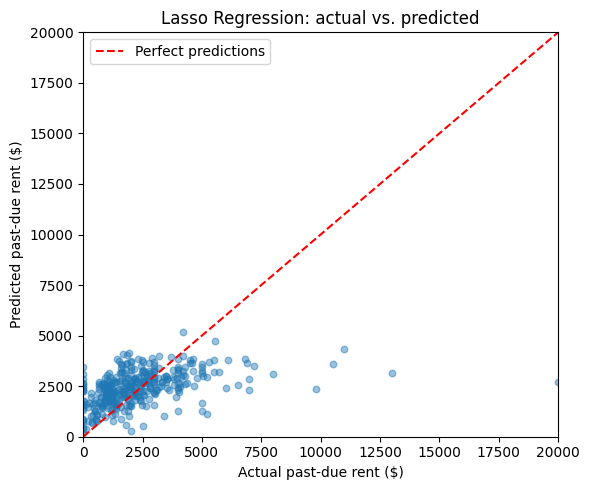

In [32]:
selected_predictions = selected_model.predict(X_test)
print(f"Selected-model MAE: ${mean_absolute_error(y_test, selected_predictions):,.2f}")
error_examples = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": selected_predictions
})
error_examples["Absolute error"] = abs(error_examples["Actual"] - error_examples["Predicted"])
display(error_examples.nlargest(5, "Absolute error").round(2).reset_index(drop=True))
actual_vs_predicted(y_test, selected_predictions, "Lasso Regression: actual vs. predicted")

Lasso performed best on this test split, with RMSE 1,827.70 and R2 0.185. Its mean absolute error is 1,183.49, meaning the average absolute prediction miss is about 1,183; RMSE is higher because it emphasizes large misses. The selected-model plot shows that predictions are concentrated in the lower-to-middle range, while the largest actual arrears are strongly underestimated. For example, the 20,000 case receives a prediction of only about $2,716. Even in the lower range, many points are far from the diagonal, so the predictions are not precise individual estimates.

Polynomial Regression did not provide a meaningful improvement: its RMSE increased relative to Linear Regression. Regularization improved the scores slightly, but Ridge and Lasso were almost tied. The hypothetical cases demonstrate that the model produces different estimates for different household profiles, not that either estimate is accurate. Overall, the available variables capture some useful patterns but leave most of the variation unexplained.

Important limitations include the single random split, rare income-source combinations, unusual records such as zero adults or zero monthly rent, and the absence of a direct measure of how long rent has gone unpaid. These deserve review rather than automatic deletion. A random split across intake quarters also does not establish performance for future quarters; a time-based evaluation would be useful before deployment. The fitted relationships are associations and should not be used as judgments of households.

## 17. What is your overall finding for SLCM?
In 5–8 sentences, explain your analysis as if you were speaking to someone from SLCM who has not taken a
machine-learning course.
Your explanation should address:
- What were you trying to predict?
- What information did you use?
- How successful was the model?
- What is the most important finding?
- Could this type of model potentially be useful for understanding community needs?
- What is one important limitation?
Do not claim that an input variable causes someone to have more or less past-due rent simply because the
model found a relationship.

I used household size, income, employment, rent, and housing-related information to predict how much past-due rent a household owed. Of the four approaches I compared, Lasso performed best on the held-out data, although Ridge was almost tied. Lasso accounted for about 18.5% of the variation in past-due rent, so its predictive ability was limited. Its average absolute error was about 1,183, and its RMSE was about 1,828 because some mistakes were much larger. The most important finding was that making the model more complicated did not improve prediction, and all four models struggled with very large amounts owed. This kind of analysis could help SLCM explore broad patterns in community needs, but these estimates are too uncertain to determine an individual's assistance. One important limitation is that the data do not directly tell us how long each household has been behind on rent, and the relationships found here do not prove that one factor causes another.